In [1]:
#import pandas as pd
#import numpy as np
#import os
#import pickle
#import matplotlib.pyplot as plt
#import seaborn as sns
#from sklearn import __version__ as sklearn_version
#from sklearn.decomposition import PCA
#from sklearn.preprocessing import scale
#from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve
#from sklearn.preprocessing import StandardScaler, MinMaxScaler
#from sklearn.dummy import DummyRegressor
#from sklearn.linear_model import LinearRegression
#from sklearn.ensemble import RandomForestRegressor
#from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
#from sklearn.pipeline import make_pipeline
#from sklearn.impute import SimpleImputer
#from sklearn.feature_selection import SelectKBest, f_regression
#import datetime

%matplotlib inline
#
# data manipulation and math
#
import numpy as np
import scipy as sp
import pandas as pd
#
# plotting and visualization
#
import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
#
import seaborn as sns
#
# modeling
#
from sklearn.preprocessing import OneHotEncoder as OHE
import sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
#

from sklearn.ensemble import RandomForestClassifier

from library.sb_utils import save_file
print("Loaded Libraries")

Loaded Libraries


In [2]:
df = pd.read_csv('data/loan_eligibility_transformed.csv')
df.head().T

,0,1,2,3,4
Dependents,0.00,2.00,0.00,0.00,1.00
Applicant_Income,2378.00,1299.00,3620.00,3459.00,5468.00
Coapplicant_Income,0.00,1086.00,0.00,0.00,1032.00
Loan_Amount,9.00,17.00,25.00,25.00,26.00
Loan_Amount_Term,360.00,120.00,120.00,120.00,360.00
Credit_History,1.00,1.00,1.00,1.00,1.00
Total_Income,2378.00,2385.00,3620.00,3459.00,6500.00
Full_Loan_Amount,9000.00,17000.00,25000.00,25000.00,26000.00
Monthly_Payment,25.00,141.67,208.33,208.33,72.22
Debt_To_Income_Ratio,1.05,5.94,5.75,6.02,1.11


In [3]:
class_counts = df['Loan_Status_N'].value_counts()
class_counts

Loan_Status_N
1    421
0    192
Name: count, dtype: int64

In [4]:
class_percentages = pd.Series([(x / df.shape[0]) * 100.00 for x in class_counts])
class_percentages

0    68.67863
1    31.32137
dtype: float64

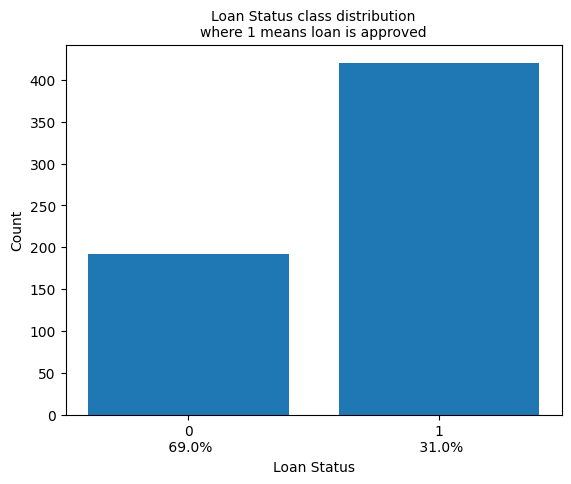

In [5]:
fig, ax = plt.subplots()
ax.bar(class_counts.index, class_counts)
ax.set_xticks([0, 1])
ax.set_xticklabels(class_percentages.index.astype(str) + '\n' + ' ' +
                   class_percentages.round(0).astype(str) + '%')
ax.set_ylabel('Count')
ax.set_xlabel('Loan Status')
ax.set_title('Loan Status class distribution\nwhere 1 means loan is approved',
              fontsize = 10)
plt.show()

In [6]:
X = df.drop(columns = ['Loan_Status_N'])
print("X: ", type(X), X.shape)
y = df['Loan_Status_N']
print("y: ", type(y), y.shape)

X:  <class 'pandas.core.frame.DataFrame'> (613, 17)
y:  <class 'pandas.core.series.Series'> (613,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, stratify = y)
X_train.head()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Total_Income,Full_Loan_Amount,Monthly_Payment,Debt_To_Income_Ratio,PA_Rural,PA_Semiurban,PA_Urban,Gender_N,Married_N,Self_Employed_N,Education_N
190,0,2253,2033.0,110,360,1,4286.0,110000,305.56,7.13,1,0,0,1,1,0,0
175,2,3617,0.0,107,360,1,3617.0,107000,297.22,8.22,0,1,0,1,0,0,1
515,0,3993,3274.0,207,360,1,7267.0,207000,575.00,7.91,0,1,0,1,1,0,1
147,0,1820,1719.0,100,360,1,3539.0,100000,277.78,7.85,0,0,1,1,1,0,1
524,0,6096,0.0,218,360,0,6096.0,218000,605.56,9.93,1,0,0,1,1,0,0


### First model: Logistic Regression with Grid Search CV

In [8]:
Cs = [0.001, 0.1, 1, 10, 100]
logreg = LogisticRegression(max_iter=10000)
# Define the grid of hyperparameters to search
param_grid = {
    'C': Cs,
    'penalty': ['l1', 'l2'],      # L1 and L2 penalties
    'solver': ['liblinear', 'sage'] # Solvers that support both l1 and l2
}
# Instantiate the grid search model
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=5,            # 5-fold cross-validation
    scoring='accuracy', # Metric to optimize (e.g., 'f1', 'roc_auc')
    verbose=1,       # Output progress
    n_jobs=-1        # Use all available processors
)
# Fit the grid search to the data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warni

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ax_iter=10000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'sage']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [9]:
# Print the best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

# Use the best estimator to make predictions or evaluate on test data
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print(f"Test set score with best model: {test_score}")

Best parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score: 0.7994254445964433
Test set score with best model: 0.8206521739130435


In [10]:
classifier = LogisticRegression(solver = 'liblinear', penalty = 'l1', max_iter = 500, C = 10, class_weight='balanced')

In [11]:
classifier.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [12]:
print(f'Accuracy on training data: {accuracy_score(classifier.predict(X_train), y_train):.2f}')

Accuracy on training data: 0.79


In [13]:
print(f'Accuracy on test data: {accuracy_score(classifier.predict(X_test), y_test):.2f}')

Accuracy on test data: 0.78


In [14]:
print("Logistic Regression: Classification Report for Training Data")
y_predict_train = classifier.predict(X_train)
print(classification_report(y_train, y_predict_train))

Logistic Regression: Classification Report for Training Data
              precision    recall  f1-score   support

           0       0.66      0.65      0.65       134
           1       0.84      0.85      0.84       295

    accuracy                           0.79       429
   macro avg       0.75      0.75      0.75       429
weighted avg       0.78      0.79      0.79       429



In [15]:
print("Logistic Regression: Classification Report for Test Data")
y_predict_test = classifier.predict(X_test)
print(classification_report(y_test, y_predict_test))

Logistic Regression: Classification Report for Test Data
              precision    recall  f1-score   support

           0       0.66      0.66      0.66        58
           1       0.84      0.84      0.84       126

    accuracy                           0.78       184
   macro avg       0.75      0.75      0.75       184
weighted avg       0.78      0.78      0.78       184



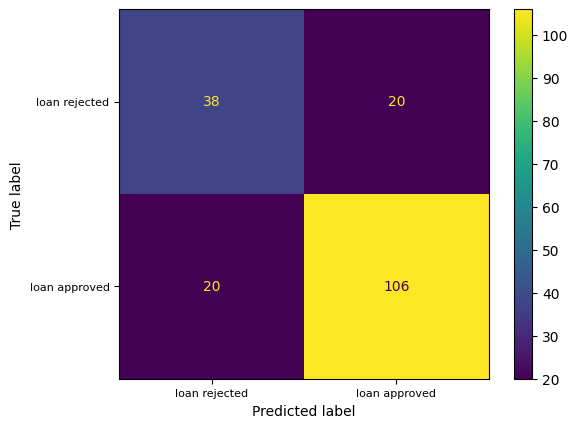

In [29]:
cm = confusion_matrix(y_test, y_predict_test, labels = classifier.classes_)
_, ax = plt.subplots()
display_cm = ConfusionMatrixDisplay(confusion_matrix = cm, 
                                    display_labels = ['loan rejected', 'loan approved'])
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels = ['loan rejected', 'loan approved'], fontsize = 8)
ax.set_yticklabels(labels = ['loan rejected', 'loan approved'], fontsize = 8)
display_cm.plot(ax = ax)
plt.show()

### Second model: Random forest

In [17]:
#scale data
from sklearn import preprocessing

# build scaler based on training data and apply it to test data to then also scale the test data
scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [18]:
clf = RandomForestClassifier(n_estimators=300, random_state = 1,n_jobs=-1)
model_res = clf.fit(X_train_scaled, y_train)
y_pred_train_rf = model_res.predict(X_train_scaled)
y_pred_test_rf = model_res.predict(X_test_scaled)
y_pred_prob_test_rf = model_res.predict_proba(X_test_scaled)
lr_probs = y_pred_prob_test_rf[:,1]
ac = accuracy_score(y_test, y_pred_test_rf)

f1 = f1_score(y_test, y_pred_test_rf, average='weighted')
cm = confusion_matrix(y_test, y_pred_test_rf)

print('Random Forest: Accuracy=%.3f' % (ac))

print('Random Forest: f1-score=%.3f' % (f1))

Random Forest: Accuracy=0.826
Random Forest: f1-score=0.817


In [19]:
print("Random Forest: Classification Report for Training Data")
print(classification_report(y_train, y_pred_train_rf))

Random Forest: Classification Report for Training Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       134
           1       1.00      1.00      1.00       295

    accuracy                           1.00       429
   macro avg       1.00      1.00      1.00       429
weighted avg       1.00      1.00      1.00       429



In [20]:
print("Random Forest: Classification Report for Test Data")
print(classification_report(y_test, y_pred_test_rf))

Random Forest: Classification Report for Test Data
              precision    recall  f1-score   support

           0       0.81      0.59      0.68        58
           1       0.83      0.94      0.88       126

    accuracy                           0.83       184
   macro avg       0.82      0.76      0.78       184
weighted avg       0.82      0.83      0.82       184



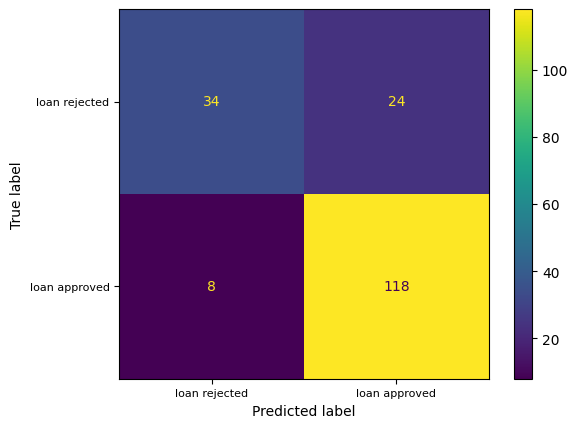

In [21]:
cm = confusion_matrix(y_test, y_pred_test_rf, labels = clf.classes_)
_, ax = plt.subplots()
display_cm = ConfusionMatrixDisplay(confusion_matrix = cm, 
                                    display_labels = ['loan rejected', 'loan approved'])
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels = ['loan rejected', 'loan approved'], fontsize = 8)
ax.set_yticklabels(labels = ['loan rejected', 'loan approved'], fontsize = 8)
display_cm.plot(ax = ax)
plt.show()

### Third model: Gradient boosting

In [22]:
#from sklearn.ensemble import GradientBoostingClassifier
#learning_rates = [0.05, 0.1, 0.25, 0.5, 0.75, 1]
#for learning_rate in learning_rates:
#    gb = GradientBoostingClassifier(n_estimators=20, learning_rate = learning_rate, max_features=2, max_depth = 2, random_state = 0)
#    gb.fit(X_train, y_train)
#    print("Learning rate: ", learning_rate)
#    print("Accuracy score (training): {0:.3f}".format(gb.score(X_train, y_train)))
#    print("Accuracy score (validation): {0:.3f}".format(gb.score(X_test, y_test)))
#    print()

In [23]:
from sklearn.ensemble import GradientBoostingClassifier

# Define the parameter grid for max_features and other parameters
param_grid = {
    'max_features': ['sqrt', 'log2', None], # Test 'sqrt', 'log2', and all features
    'max_depth': [3, 5, 8],                 # Also tune max_depth
    'n_estimators': [20],                  # Fix n_estimators for this step
    'learning_rate': [0.1, 0.1, 0.25, 0.5, 0.75, 1]                 # Fix learning rate
}

# Create a GradientBoostingClassifier
gbc = GradientBoostingClassifier(random_state=42)

# Instantiate GridSearchCV
# Use an appropriate scoring metric, e.g., 'roc_auc' or 'accuracy'
grid_search = GridSearchCV(estimator=gbc, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters found
print(f"Best parameters found: {grid_search.best_params_}")

# Use the best estimator
best_gbc = grid_search.best_estimator_
test_score = best_gbc.score(X_test_scaled, y_test)
print(f"Test accuracy of the best model: {test_score:.4f}")

Best parameters found: {'learning_rate': 0.25, 'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 20}
Test accuracy of the best model: 0.8315


In [24]:
gb = GradientBoostingClassifier(n_estimators=20, learning_rate = 0.25, max_features='sqrt', max_depth = 3, random_state = 0)
gb_model = gb.fit(X_train_scaled, y_train)
#y_pred = gb_model.predict(X_test)
y_pred_train_gb = gb_model.predict(X_train_scaled)
y_pred_test_gb = gb_model.predict(X_test_scaled)
y_pred_prob_test_gb = gb_model.predict_proba(X_test_scaled)

ac = accuracy_score(y_test, y_pred_test_gb)
print(f"Accuracy: {ac:.2f}")

Accuracy: 0.82


In [25]:
print("Gradient Boosting: Classification Report for Training Data")
print(classification_report(y_train, y_pred_train_gb))

Gradient Boosting: Classification Report for Training Data
              precision    recall  f1-score   support

           0       0.93      0.62      0.74       134
           1       0.85      0.98      0.91       295

    accuracy                           0.87       429
   macro avg       0.89      0.80      0.83       429
weighted avg       0.88      0.87      0.86       429



In [26]:
print("Gradient Boosting: Classification Report for Test Data")
print(classification_report(y_test, y_pred_test_gb))

Gradient Boosting: Classification Report for Test Data
              precision    recall  f1-score   support

           0       0.82      0.55      0.66        58
           1       0.82      0.94      0.88       126

    accuracy                           0.82       184
   macro avg       0.82      0.75      0.77       184
weighted avg       0.82      0.82      0.81       184



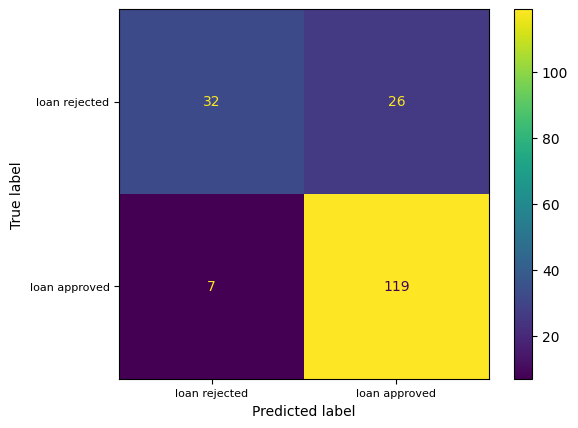

In [27]:
cm_gb = confusion_matrix(y_test, y_pred_test_gb, labels = gb.classes_)
_, ax = plt.subplots()
display_cm = ConfusionMatrixDisplay(confusion_matrix = cm_gb, 
                                    display_labels = ['loan rejected', 'loan approved'])
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels = ['loan rejected', 'loan approved'], fontsize = 8)
ax.set_yticklabels(labels = ['loan rejected', 'loan approved'], fontsize = 8)
display_cm.plot(ax = ax)
plt.show()

In [28]:
gb.classes_

array([0, 1])